# sklearn Machine Learning Examples

This notebook demonstrates classification, regression, dimensionality reduction, and clustering using sklearn.


## 1. Classification Example


In [3]:
%pip install scikit-learn numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


# Create the Data

### What we're importing

- **Toolbox = library** (`sklearn`), installed once with `pip install scikit-learn`
- **Drawer = module** (`sklearn.metrics`, `sklearn.linear_model`)
- **Tool = the thing you import** (`accuracy_score`)

*(You'll also hear "package"; people use it interchangeably with "library".)*

| Import | Type | What it's for |
|---|---|---|
| `pandas` | Library | Tables (DataFrames): load, clean and manipulate data, like Excel in code |
| `numpy` | Library | Fast math on numbers; the engine underneath pandas and sklearn |
| `train_test_split` | Tool from sklearn | Splits data into a **training** set (to learn from) and a **test** set (to check on unseen data) |
| `StandardScaler` | Tool from sklearn | Puts all features on the same scale so big numbers don't dominate |
| `VarianceThreshold` | Tool from sklearn | Removes features that never change, since they carry no information |
| `LogisticRegression` | Tool from sklearn (model) | Simple, explainable model for yes/no predictions |
| `RandomForestClassifier` | Tool from sklearn (model) | Many decision trees voting together; usually stronger, less explainable |
| `accuracy_score`, `precision_score`, ... | Tools from sklearn (metrics) | Different ways to measure how good the predictions are |
| `warnings` | Built into Python | Hides non-critical warning messages (no install needed) |

**sklearn** (scikit-learn) is the main machine learning library we use today.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold  # Correct import
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.shape

(891, 12)

In [8]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

### 1.2 Feature Engineering

**Feature engineering = getting the data ready so a model can learn from it.**
Raw data is messy: empty cells, text instead of numbers, useless columns. Models only understand clean numbers.

**The usual steps:**
1. **Handle missing values**: fill them in or remove them
2. **Turn categories into numbers**: e.g. "male"/"female" → 1/0
3. **Remove useless columns**: columns that never change
4. **Remove duplicate-like columns**: columns that say the same thing as another one
5. **Separate features and target**: inputs (X) vs. what we want to predict (y)
6. **Split into train and test**: learn on one part, check on the other

*(Feature engineering can also mean creating new columns, e.g. family size = siblings + parents. We keep it simple here.)*

#### Step 1: Fill missing values
Some passengers have no **Age** or **Embarked** (port of departure) recorded.
- **Numbers** (Age) → fill with the **median** (the middle value; extreme ages don't distort it)
- **Categories** (Embarked) → fill with the **mode** (the most common value)

In [9]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

#### Step 2: Turn categories into numbers (`get_dummies`)
Models only understand numbers, not words like "male" or "S".
`get_dummies` turns each category into its own 0/1 column:
- `Sex` → `Sex_male` (1 = male, 0 = female)
- `Embarked` → `Embarked_Q`, `Embarked_S` (port Q, port S; if both are 0, it was port C)

`drop_first=True` drops one column because it's redundant: if you're not male, you're female.

In [11]:
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True, dtype=int)

#### Step 3: Keep only number columns
Columns like **Name**, **Ticket** and **Cabin** are free text the model can't use directly, so we keep only number columns.
Then we fill any remaining empty cells with the median, just to be safe.

In [12]:
df = df.select_dtypes(include=[np.number])
df = df.fillna(df.median(numeric_only=True))

#### Step 4: Remove columns that never change (Variance Threshold)
A column with the same value in every row (e.g. "country = UK" for everyone) tells the model nothing.
`VarianceThreshold(threshold=0.0)` removes any column that never changes.

In [17]:
selector = VarianceThreshold(threshold=0.0)
X_temp = df.drop('Survived', axis=1)
selector.fit(X_temp)
selected_features = X_temp.columns[selector.get_support()]
df = df[list(selected_features) + ['Survived']]

#### Step 5: Remove duplicate-like columns (high correlation)
**Correlation** measures how closely two columns move together:
- close to **+1** → when one goes up, the other goes up
- close to **−1** → when one goes up, the other goes down
- close to **0** → no link

**Simple example:** imagine a table with both of these columns:

| Person | Birth year | Age |
|---|---|---|
| A | 1960 | 64 |
| B | 1990 | 34 |
| C | 2005 | 19 |

The later the birth year, the younger the person, every time. Correlation = **−1** (a perfect link, just in the opposite direction).
Birth year adds **no new information** once we know the age; it's the same fact said twice. So we keep **Age** (easier to understand) and drop **Birth year**.

Other everyday examples: *height in cm and in inches*, *price in € and in $*.

The rule in our code: if two columns have a correlation **above 0.95 or below −0.95**, drop one of them. (That's what `.abs()` does: it ignores the direction.)

*This is a safety check; on this dataset it may not drop anything.*

In [18]:
correlation_matrix = df.drop('Survived', axis=1).corr().abs()
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)
high_corr_features = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.95)]
df = df.drop(columns=high_corr_features)

#### Step 6: Separate features and target, then split
- **X = features**: the inputs the model looks at (age, class, fare, ...)
- **y = target**: what we want to predict (`Survived`: 1 = yes, 0 = no)
- **Train / test split**: 80% of passengers to learn from, 20% kept aside to check the model on data it has never seen
- `random_state=42` makes the split the same every time we run it

In [20]:
X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 1.3 Logistic Regression

**Every sklearn model follows the same recipe:**
1. **Prepare** the data (scale it, if the model needs it)
2. **Create** the model → `model = LogisticRegression()`
3. **Train** it on the training data → `model.fit(X_train, y_train)`
4. **Predict** on the test data → `model.predict(X_test)`
5. **Evaluate** how good the predictions are (section 1.5)

#### Step 1: Scale the data (`StandardScaler`)
Our columns have very different ranges:

| Column | Range |
|---|---|
| Sex_male | 0 – 1 |
| Age | 0 – 80 |
| Fare | 0 – 512 |

Logistic Regression works with the size of the numbers, so **Fare would look more important just because its numbers are bigger**.
`StandardScaler` puts every column on the same scale (average 0, spread 1), so each one gets a fair chance.

- `fit_transform(X_train)` → **learn** the averages from the training data, then scale it
- `transform(X_test)` → scale the test data using those **same** averages (the test data must stay "unseen", so we don't learn anything from it)

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Step 2: Create, train and predict
- **Create**: `LogisticRegression(...)` sets up an empty model (`max_iter=1000` gives it enough attempts to learn)
- **Train**: `.fit()` shows the model the training passengers *and* whether they survived, so it learns the pattern
- **Predict**: the model now sees the test passengers *without* the answer:
  - `.predict()` → a yes/no answer for each passenger (1 = survived, 0 = didn't)
  - `.predict_proba()` → the **probability** of survival (e.g. 0.73 = 73% chance)

In [22]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

### 1.4 Random Forest


In [24]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]


### 1.5 Model Comparison


In [25]:
metrics = {
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred)
    ],
    'F1-Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred)
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, lr_pred_proba),
        roc_auc_score(y_test, rf_pred_proba)
    ]
}

comparison_df = pd.DataFrame(metrics)
print(comparison_df)


                 Model  Accuracy  Precision    Recall  F1-Score   AUC-ROC
0  Logistic Regression  0.804469   0.774648  0.743243  0.758621  0.875676
1        Random Forest  0.821229   0.808824  0.743243  0.774648  0.890283


## 2. Regression Example


### 2.1 Data Loading and Preparation


In [26]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import PowerTransformer
from sklearn.feature_selection import VarianceThreshold  

house_df = pd.read_csv('https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv')
house_df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [27]:
house_df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

### 2.2 Feature Engineering

Same idea as in 1.2: get the data ready for the model. The big difference is the **target**:
- Titanic: *Survived?* → yes/no → **classification**
- Housing: *median_house_value* → a price (a number) → **regression**

**Missing values:** `total_bedrooms` has 207 empty cells. We don't fill them here; we fill them later, inside each model's steps (2.3 and 2.4), using the training data only.

#### Step 1: Turn categories into numbers (`get_dummies`)
`ocean_proximity` is text with 5 categories: `<1H OCEAN`, `INLAND`, `NEAR OCEAN`, `NEAR BAY`, `ISLAND`.
`get_dummies` turns it into 0/1 columns, one per category (minus the first one, as in 1.2).

In [28]:
house_df = pd.get_dummies(house_df, columns=['ocean_proximity'], drop_first=True, dtype=int)

#### Step 2: Keep only number columns
Same as in 1.2: we keep only columns the model can read as numbers.

In [29]:
house_df = house_df.select_dtypes(include=[np.number])

#### Step 3: Remove columns that never change (Variance Threshold)
Same as in 1.2: any column with the same value in every row is removed.

In [32]:
selector_house = VarianceThreshold(threshold=0.0)
X_temp_house = house_df.drop('median_house_value', axis=1)
selector_house.fit(X_temp_house)
selected_features_house = X_temp_house.columns[selector_house.get_support()]
house_df = house_df[list(selected_features_house) + ['median_house_value']]

In [34]:
dropped_features_house = X_temp_house.columns[~selector_house.get_support()]
print("Dropped:", list(dropped_features_house))

Dropped: []


#### Step 4: Remove duplicate-like columns (high correlation)
Here the check **does** find something: `households` and `total_bedrooms` have a correlation of about **0.98**.
That makes sense: more households in a district → more bedrooms. They tell the model almost the same thing, so `households` is dropped.

In [35]:
correlation_matrix = house_df.drop('median_house_value', axis=1).corr().abs()
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)
high_corr_features = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.95)]
house_df = house_df.drop(columns=high_corr_features)

In [36]:
high_corr_features

['households']

#### Step 5: Separate features and target, then split
- **X = features**: everything about the district (location, rooms, income, ...)
- **y = target**: `median_house_value`, the price we want to predict
- 80% of districts to learn from, 20% kept aside to test

In [37]:
X_house = house_df.drop('median_house_value', axis=1)
y_house = house_df['median_house_value']
X_train_house, X_test_house, y_train_house, y_test_house = train_test_split(
    X_house, y_house, test_size=0.2, random_state=42
)

### 2.3 KNN Regression


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

knn_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('power_transformer', PowerTransformer(method='yeo-johnson')),
    ('knn', KNeighborsRegressor(n_neighbors=5))
])

knn_pipeline.fit(X_train_house, y_train_house)
knn_pred = knn_pipeline.predict(X_test_house)

### 2.4 Linear Regression

**Linear Regression** draws the best straight-line formula through the data:
> price = (a × income) + (b × rooms) + (c × location) + ...

It learns the numbers a, b, c from the training data. It's simple and easy to explain to a client: *"every extra unit of income adds about X to the price."*

**Here we prepare the data by hand**, step by step. It's the same kind of work the pipeline did automatically in 2.3. Compare the two!

#### Step 1: Fill missing values
`total_bedrooms` has empty cells. We fill them with the **median from the training data**, for both train and test (the test data stays unseen).

In [23]:
X_train_lr = X_train_house.fillna(X_train_house.median())
X_test_lr = X_test_house.fillna(X_train_house.median())

#### Step 2: Scale the data (`StandardScaler`)
Same as in 1.3: `population` is in the thousands, `median_income` is around 0–15.
Scaling puts all columns on the same scale so the formula's numbers (a, b, c, ...) can be compared fairly.

- `fit_transform` on train → learn the averages and scale
- `transform` on test → reuse the **same** averages

In [24]:
scaler_lr = StandardScaler()
X_train_lr_scaled = scaler_lr.fit_transform(X_train_lr)
X_test_lr_scaled = scaler_lr.transform(X_test_lr)

#### Step 3: Remove duplicate-like columns (again)
Linear Regression gets confused when two columns say the same thing: it can't tell which one deserves the credit.
So we run the correlation check once more, this time on the **training data only**.

*We already did this in 2.2 (it dropped `households`), so this is a safety check and likely drops nothing new.*

In [25]:
correlation_matrix_lr = pd.DataFrame(X_train_lr_scaled).corr().abs()
upper_triangle_lr = correlation_matrix_lr.where(
    np.triu(np.ones(correlation_matrix_lr.shape), k=1).astype(bool)
)
high_corr_features_lr = [column for column in upper_triangle_lr.columns if any(upper_triangle_lr[column] > 0.95)]
X_train_lr_scaled = pd.DataFrame(X_train_lr_scaled).drop(columns=high_corr_features_lr).values
X_test_lr_scaled = pd.DataFrame(X_test_lr_scaled).drop(columns=high_corr_features_lr).values

#### Step 4: Create, train and predict
Same recipe as every sklearn model:
- **Create**: `LinearRegression()`
- **Train**: `.fit()` learns the formula from the training districts and their prices
- **Predict**: `.predict()` estimates a price for each test district

*(No `predict_proba` here: we predict a number, not a yes/no.)*

In [26]:
lr_reg_model = LinearRegression()
lr_reg_model.fit(X_train_lr_scaled, y_train_house)
lr_reg_pred = lr_reg_model.predict(X_test_lr_scaled)

### 2.5 Model Comparison


In [27]:
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

regression_metrics = {
    'Model': ['KNN Regression', 'Linear Regression'],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test_house, knn_pred)),
        np.sqrt(mean_squared_error(y_test_house, lr_reg_pred))
    ],
    'MAE': [
        mean_absolute_error(y_test_house, knn_pred),
        mean_absolute_error(y_test_house, lr_reg_pred)
    ],
    'R2': [
        r2_score(y_test_house, knn_pred),
        r2_score(y_test_house, lr_reg_pred)
    ],
    'MAPE': [
        mean_absolute_percentage_error(y_test_house, knn_pred),
        mean_absolute_percentage_error(y_test_house, lr_reg_pred)
    ]
}

regression_comparison_df = pd.DataFrame(regression_metrics)
print(regression_comparison_df)


               Model          RMSE           MAE        R2       MAPE
0     KNN Regression  63120.261196  42799.195349  0.695960  24.076814
1  Linear Regression  71878.817762  52166.426001  0.605729  31.200131


### Discussion: are these good models?

#### What the numbers mean
A typical house in this data costs about **$180,000**.

| Metric | In plain words | KNN | Linear Regression |
|---|---|---|---|
| **MAE** | On average, how far off is the price? | ~$43,000 | ~$52,000 |
| **RMSE** | Like MAE, but big mistakes count extra | ~$63,000 | ~$72,000 |
| **R²** | How much of the price differences does the model explain? (0 = nothing, 1 = everything) | 70% | 61% |
| **MAPE** | On average, how far off in **%**? | ~24% | ~31% |

**Lower is better** for MAE, RMSE and MAPE. **Higher is better** for R².

#### Discuss in your group
1. **Is being 24% off "good"?** Think about who uses the model: someone browsing house prices online, or a bank deciding how much money to lend?
2. **Which model would you recommend to a client?** KNN is more accurate. Linear Regression is easier to explain. Which matters more, and when?
3. **Linear Regression predicted a *negative* price for some houses.** What does that tell you about trusting a model just because its scores look OK?
4. **How could we make the predictions better?** Think about the data, not just the model.

> 💡 **Key idea:** whether a model is "good" is a **business question**, not just a technical one. It depends on what decision it supports and what a mistake costs.

## 3. PCA with Normalization

**PCA (Principal Component Analysis) = fewer columns, almost the same information.**

Some of our columns say similar things (e.g. rooms, bedrooms and population all mean "big district").
PCA builds a few **new columns** (called *components*), each a mix of all the old ones, and keeps only the most useful.

**What happens here:**
> We squeeze **7 columns into 4 new ones** and keep **96% of the differences between districts**.

- **Before PCA:** scale the data, so big numbers (like population) don't dominate
- **Downside:** the new columns have no simple meaning ("PC1" is not a real-world column), so they're harder to explain to a client

### 3.1 Data Preparation


In [39]:
house_df.shape

(20640, 12)

In [40]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_df = house_df.copy()
X_pca = pca_df.drop('median_house_value', axis=1)
X_pca = X_pca.fillna(X_pca.median())


### 3.2 Normalization and PCA


In [29]:
scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(X_pca)

pca = PCA(n_components=0.95)
X_pca_transformed = pca.fit_transform(X_pca_scaled)

print(f"Original features: {X_pca_scaled.shape[1]}")
print(f"PCA components (95% variance): {X_pca_transformed.shape[1]}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")


Original features: 7
PCA components (95% variance): 4
Explained variance ratio: 0.9630


### 3.3 Variance Explained Visualization

**Left graph:** each dot is one neighbourhood, squeezed from 7 columns onto a 2D map. Dots close together are similar neighbourhoods; most sit in one crowded area, a few far-away dots are unusual, and the two bands hint at natural groups.

**Right graph:** the bars show how much information each new column carries (43%, 27%, 15%, 12%). The red line adds them up, and crosses the 95% goal at column 4, which is why PCA kept 4 columns.

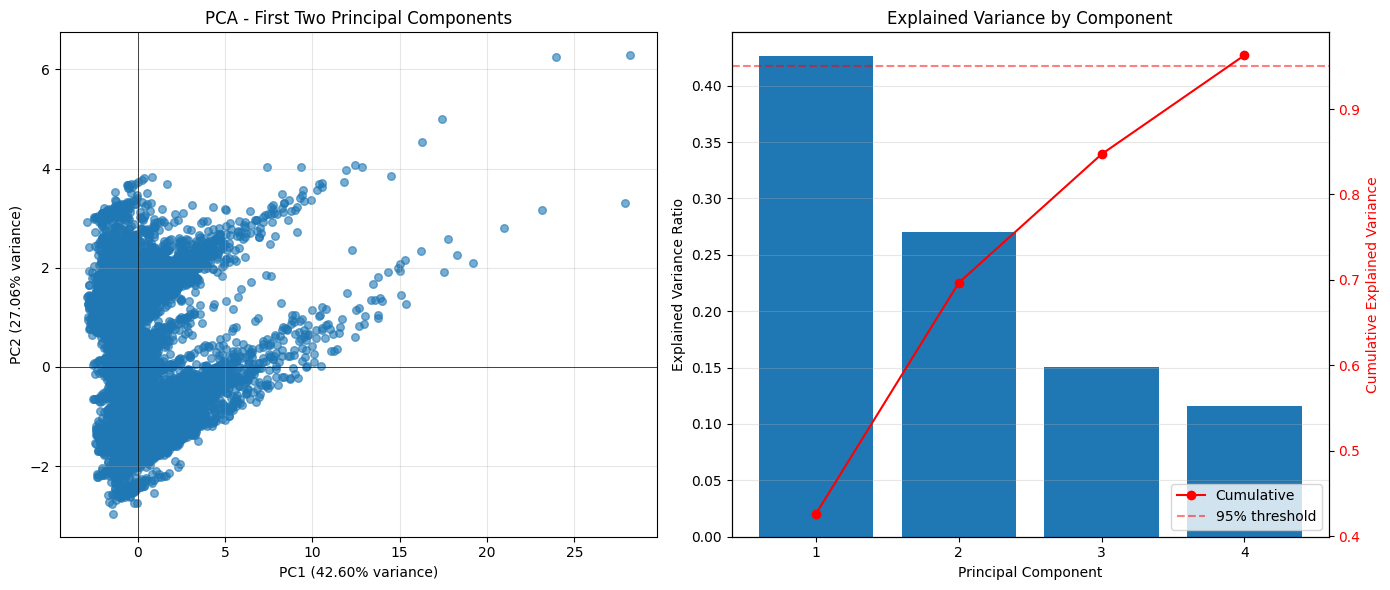

Variance explained by PC1: 0.4260
Variance explained by PC2: 0.2706
Total variance (first 2 components): 0.6966


In [30]:

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_pca_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], alpha=0.6, s=30)
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} variance)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} variance)')
axes[0].set_title('PCA - First Two Principal Components')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[0].axvline(x=0, color='k', linestyle='-', linewidth=0.5)

n_components_to_show = min(10, len(pca.explained_variance_ratio_))
axes[1].bar(range(1, n_components_to_show + 1), 
            pca.explained_variance_ratio_[:n_components_to_show])
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Explained Variance Ratio')
axes[1].set_title('Explained Variance by Component')
axes[1].set_xticks(range(1, n_components_to_show + 1))
axes[1].grid(True, alpha=0.3, axis='y')

cumsum_var = np.cumsum(pca.explained_variance_ratio_[:n_components_to_show])
ax2 = axes[1].twinx()
ax2.plot(range(1, n_components_to_show + 1), cumsum_var, 'r-', marker='o', label='Cumulative')
ax2.set_ylabel('Cumulative Explained Variance', color='r')
ax2.tick_params(axis='y', labelcolor='r')
ax2.axhline(y=0.95, color='r', linestyle='--', alpha=0.5, label='95% threshold')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Variance explained by PC1: {pca_2d.explained_variance_ratio_[0]:.4f}")
print(f"Variance explained by PC2: {pca_2d.explained_variance_ratio_[1]:.4f}")
print(f"Total variance (first 2 components): {pca_2d.explained_variance_ratio_.sum():.4f}")

## 4. K-Means Clustering with Elbow Method


### 4.1 Data Preparation


In [41]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_selection import VarianceThreshold  

kmeans_df = house_df.copy()
X_kmeans = kmeans_df.drop('median_house_value', axis=1)
X_kmeans = X_kmeans.fillna(X_kmeans.median())


### 4.2 Feature Engineering

Same cleaning steps as before, with one big difference: **there is no target and no train/test split.**
K-Means doesn't predict anything; it just looks for **groups of similar neighbourhoods** in all the data.

#### Step 1: Keep only number columns
A safety check: K-Means can only work with numbers.

In [42]:
X_kmeans = X_kmeans.select_dtypes(include=[np.number])

#### Step 2: Remove columns that never change (Variance Threshold)
Same as in 1.2: a column with the same value everywhere can't help tell groups apart.

In [43]:
selector_km = VarianceThreshold(threshold=0.0)
selector_km.fit(X_kmeans)
selected_features_km = X_kmeans.columns[selector_km.get_support()]
X_kmeans = X_kmeans[selected_features_km]

#### Step 3: Remove duplicate-like columns (high correlation)
Same as in 1.2 and 2.2. If two columns say the same thing, K-Means would count that fact **twice** when comparing neighbourhoods. So we keep only one.

In [44]:
correlation_matrix_km = X_kmeans.corr().abs()
upper_triangle_km = correlation_matrix_km.where(
    np.triu(np.ones(correlation_matrix_km.shape), k=1).astype(bool)
)
high_corr_features_km = [column for column in upper_triangle_km.columns if any(upper_triangle_km[column] > 0.95)]
X_kmeans = X_kmeans.drop(columns=high_corr_features_km)

#### Step 4: Scale and reshape the data
K-Means groups neighbourhoods by **how close they are**, just like KNN in 2.3. So we do the same two things:
- `StandardScaler`: puts all columns on the same scale, so `population` (thousands) doesn't drown out `median_income` (0–15)
- `PowerTransformer`: squashes extreme values, so a few huge neighbourhoods don't stretch everything

In [45]:
scaler_km = StandardScaler()
transformer_km = PowerTransformer(method='yeo-johnson')

X_kmeans_scaled = scaler_km.fit_transform(X_kmeans)
X_kmeans_transformed = transformer_km.fit_transform(X_kmeans_scaled)

### 4.3 Elbow Method


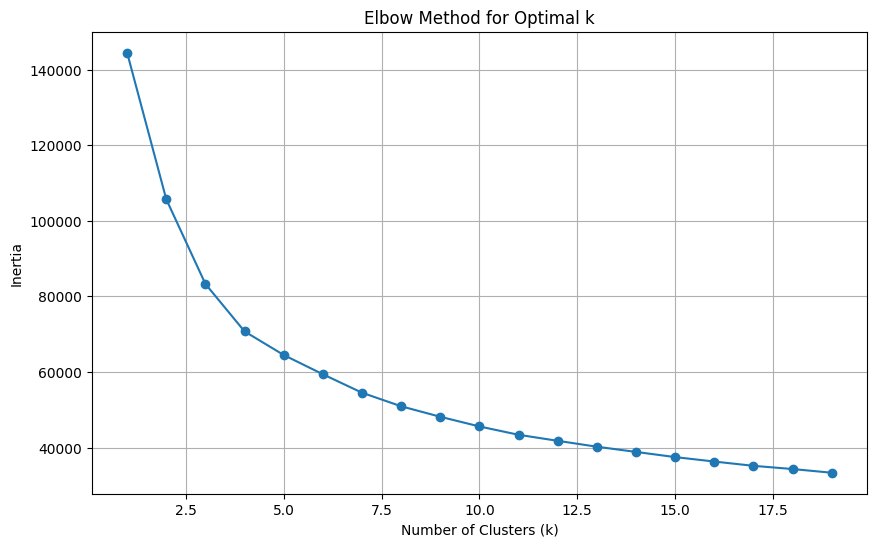

In [46]:
inertias = []
K_range = range(1, 20)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_kmeans_transformed)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()


### 4.4 Final K-Means Model


In [46]:
optimal_k = 2
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = final_kmeans.fit_predict(X_kmeans_transformed)

silhouette_avg = silhouette_score(X_kmeans_transformed, clusters)
print(f"Optimal k: {optimal_k}")
print(f"Silhouette Score: {silhouette_avg:.4f}")
print(f"Cluster sizes: {np.bincount(clusters)}")


Optimal k: 2
Silhouette Score: 0.2150
Cluster sizes: [11533  9107]


#### What is the Silhouette Score?
It checks: **is each neighbourhood clearly in its own group, or sitting on the fence between two groups?**

Think of a party where people stand in groups. For each person: *"Am I much closer to my own group than to the next one?"*

| Score | Meaning |
|---|---|
| close to **+1** | Clear, well-separated groups |
| around **0** | On the border; groups overlap |
| **negative** | Probably in the wrong group |

**Our score: 0.23** → the two groups exist, but they **overlap a lot**. Many neighbourhoods are "fence-sitters".
Not every dataset has neat, natural groups, and that's an honest finding too.

*Elbow vs. Silhouette:* the elbow only checks how **tight** each group is. Silhouette also checks how **far apart** the groups are, so a higher score is simply better.

### Visualizations

In [36]:
X_kmeans['Cluster'] = clusters

cluster_summary = X_kmeans.groupby('Cluster').agg(['mean', 'std', 'count'])

print("=" * 80)
print("CLUSTER CHARACTERISTICS - Mean Values")
print("=" * 80)
for cluster_id in range(optimal_k):
    print(f"\n--- Cluster {cluster_id} (n={np.sum(clusters == cluster_id)}) ---")
    cluster_means = X_kmeans[X_kmeans['Cluster'] == cluster_id].drop('Cluster', axis=1).mean()
    print(cluster_means.sort_values(ascending=False))


CLUSTER CHARACTERISTICS - Mean Values

--- Cluster 0 (n=9717) ---
total_rooms           3940.323248
population            2102.166409
total_bedrooms         796.717094
latitude                35.229194
housing_median_age      23.118143
median_income            4.058788
longitude             -119.188280
dtype: float64

--- Cluster 1 (n=10923) ---
total_rooms           1475.238396
population             823.499863
total_bedrooms         305.653575
latitude                35.990070
housing_median_age      33.551222
median_income            3.703324
longitude             -119.909016
dtype: float64


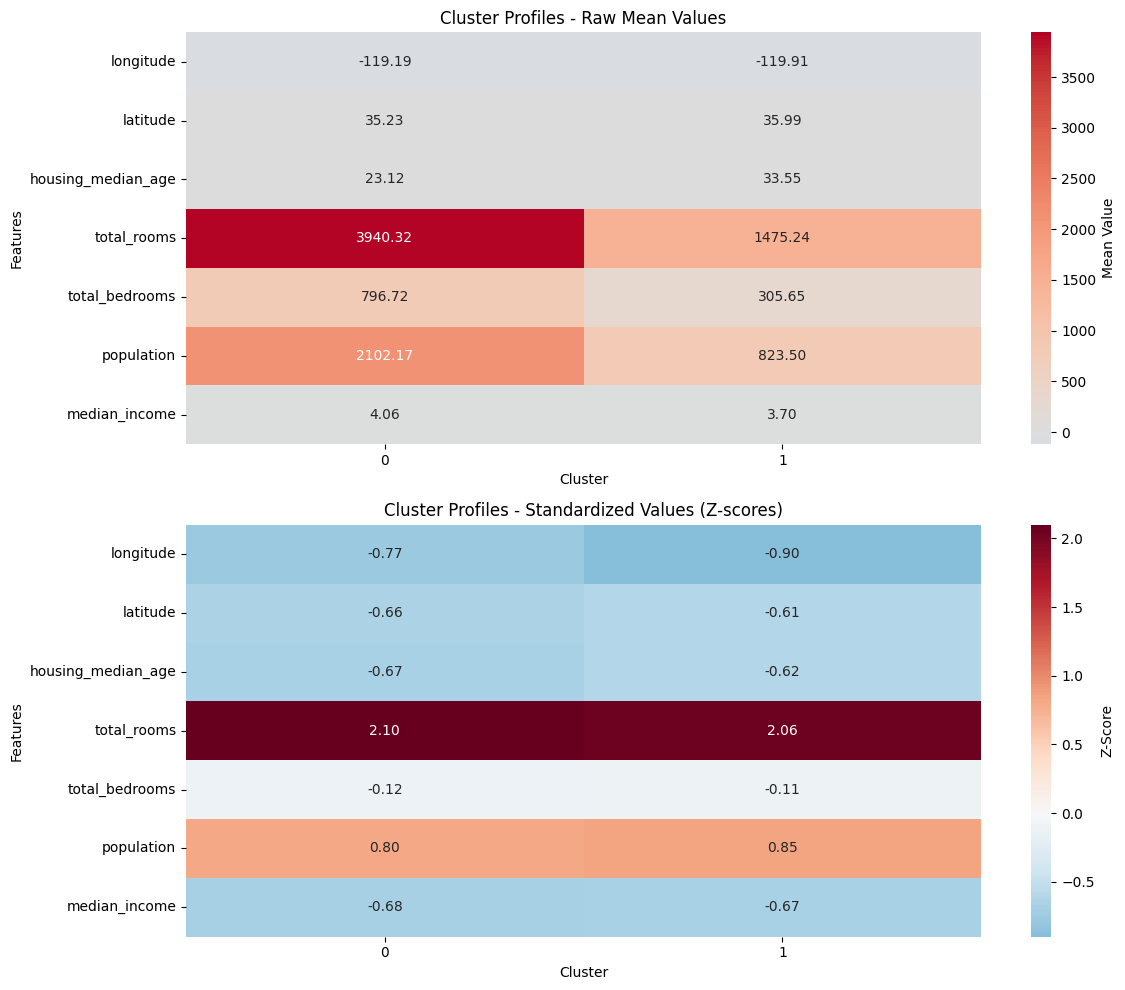

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

cluster_profiles = X_kmeans.groupby('Cluster').mean()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cluster_profiles_scaled = pd.DataFrame(
    scaler.fit_transform(cluster_profiles.T).T,
    index=cluster_profiles.index,
    columns=cluster_profiles.columns
)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

sns.heatmap(cluster_profiles.T, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=axes[0], cbar_kws={'label': 'Mean Value'})
axes[0].set_title('Cluster Profiles - Raw Mean Values')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Features')

# Heatmap 2: Standardized values (z-scores)
sns.heatmap(cluster_profiles_scaled.T, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, ax=axes[1], cbar_kws={'label': 'Z-Score'})
axes[1].set_title('Cluster Profiles - Standardized Values (Z-scores)')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Features')

plt.tight_layout()
plt.show()

In [39]:
print("\n" + "=" * 80)
print("FEATURE IMPORTANCE FOR CLUSTERING")
print("=" * 80)

feature_importance = cluster_profiles.var(axis=0).sort_values(ascending=False)
print("\nFeatures with highest variance across clusters (most discriminative):")
print(feature_importance)

print("\n" + "=" * 80)
print("DETAILED CLUSTER COMPARISON")
print("=" * 80)
comparison_df = pd.DataFrame()
for i in range(optimal_k):
    comparison_df[f'Cluster_{i}'] = X_kmeans[X_kmeans['Cluster'] == i].drop('Cluster', axis=1).mean()

comparison_df = comparison_df.T
print(comparison_df.round(2))

print("\n" + "=" * 80)
print("DISTINCTIVE FEATURES PER CLUSTER")
print("=" * 80)
for cluster_id in range(optimal_k):
    print(f"\n--- Cluster {cluster_id} ---")
    cluster_data = cluster_profiles_scaled.loc[cluster_id].sort_values(ascending=False)
    high_features = cluster_data[cluster_data > 1.5].index.tolist()
    low_features = cluster_data[cluster_data < -1.5].index.tolist()
    
    if high_features:
        print(f"Notably HIGH: {', '.join(high_features)}")
    if low_features:
        print(f"Notably LOW: {', '.join(low_features)}")
    if not high_features and not low_features:
        print("No extremely distinctive features (moderate values)")



FEATURE IMPORTANCE FOR CLUSTERING

Features with highest variance across clusters (most discriminative):
total_rooms           3.038322e+06
population            8.174941e+05
total_bedrooms        1.205717e+05
housing_median_age    5.442457e+01
latitude              2.894664e-01
longitude             2.597298e-01
median_income         6.317742e-02
dtype: float64

DETAILED CLUSTER COMPARISON
           longitude  latitude  housing_median_age  total_rooms  \
Cluster_0    -119.19     35.23               23.12      3940.32   
Cluster_1    -119.91     35.99               33.55      1475.24   

           total_bedrooms  population  median_income  
Cluster_0          796.72     2102.17           4.06  
Cluster_1          305.65      823.50           3.70  

DISTINCTIVE FEATURES PER CLUSTER

--- Cluster 0 ---
Notably HIGH: total_rooms

--- Cluster 1 ---
Notably HIGH: total_rooms


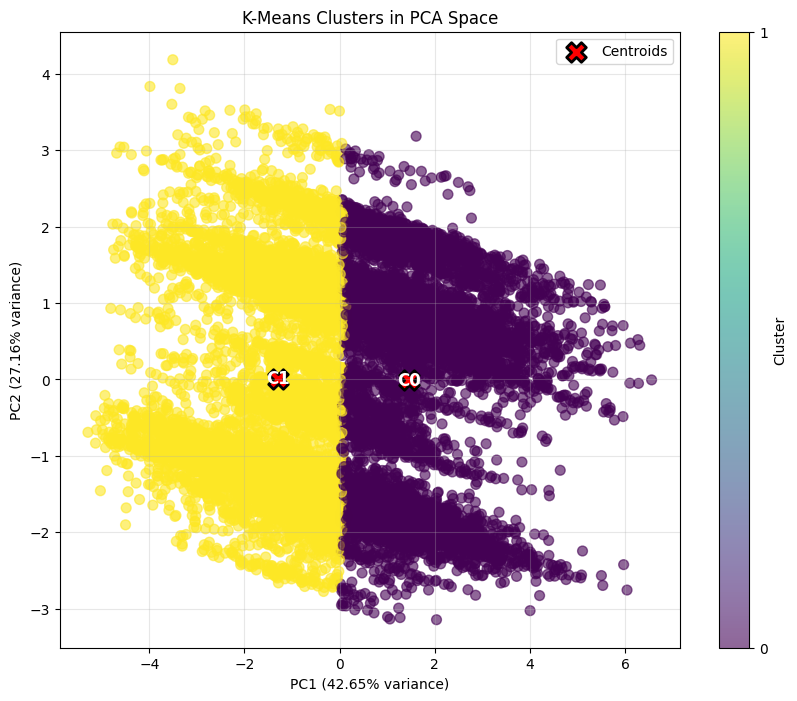

In [40]:
from sklearn.decomposition import PCA

pca_viz = PCA(n_components=2)
X_pca_viz = pca_viz.fit_transform(X_kmeans_transformed)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca_viz[:, 0], X_pca_viz[:, 1], 
                     c=clusters, cmap='viridis', alpha=0.6, s=50)
plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]:.2%} variance)')
plt.title('K-Means Clusters in PCA Space')
plt.colorbar(scatter, label='Cluster', ticks=range(optimal_k))

# Add cluster centers
centers_pca = pca_viz.transform(final_kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], 
           c='red', marker='X', s=200, edgecolors='black', linewidth=2,
           label='Centroids')

# Add cluster labels
for i, (x, y) in enumerate(centers_pca):
    plt.annotate(f'C{i}', (x, y), fontsize=12, fontweight='bold',
                ha='center', va='center', color='white')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Clean up - remove the cluster column if you want to keep original data intact
X_kmeans = X_kmeans.drop('Cluster', axis=1)